In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn-selected-columns.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,Yes


In [ ]:
df.shape

(7043, 11)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customerID       7043 non-null   object
 1   gender           7043 non-null   object
 2   SeniorCitizen    7043 non-null   int64 
 3   Partner          7043 non-null   object
 4   Dependents       7043 non-null   object
 5   tenure           7043 non-null   int64 
 6   PhoneService     7043 non-null   object
 7   MultipleLines    7043 non-null   object
 8   InternetService  7043 non-null   object
 9   OnlineSecurity   7043 non-null   object
 10  Churn            7043 non-null   object
dtypes: int64(2), object(9)
memory usage: 605.4+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0


In [ ]:
# Missing Values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Separate num. and cat. columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

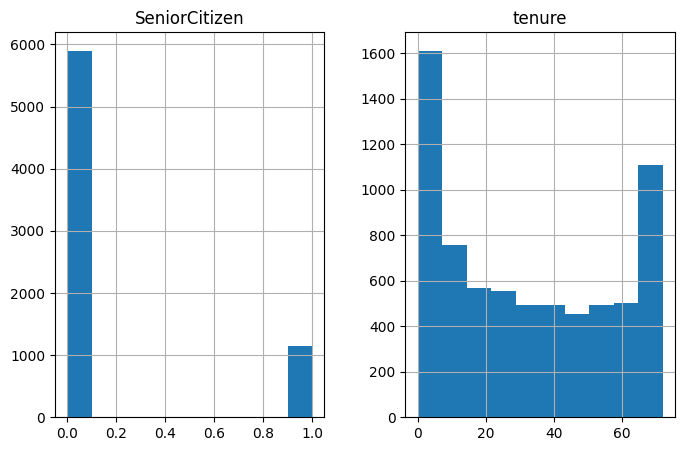

In [ ]:
# Histogram
df.hist(figsize=(8,5))
plt.show()

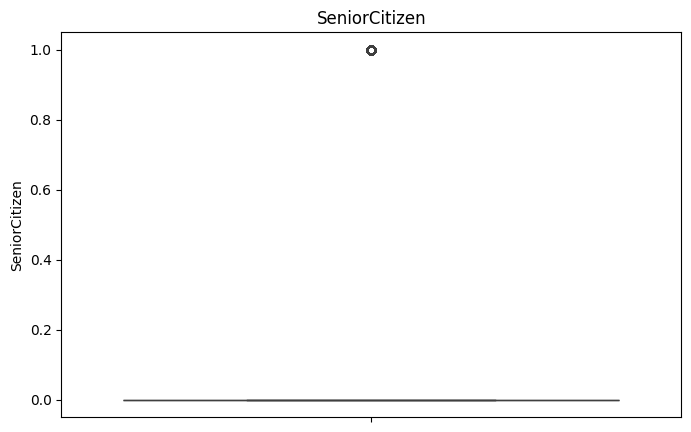

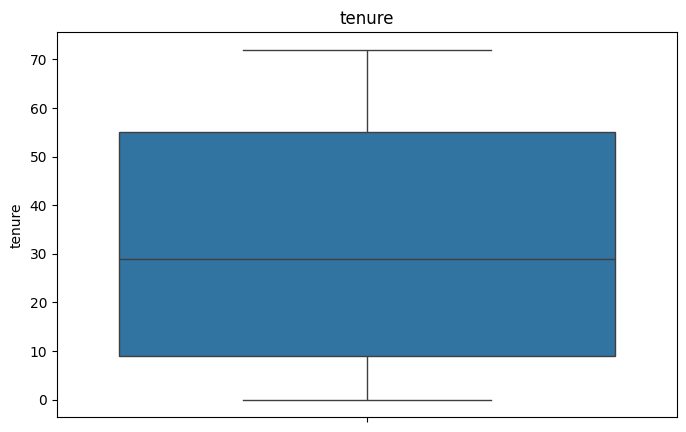

In [ ]:
# Box Plot
for col in num_cols:
  plt.figure(figsize=(8,5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

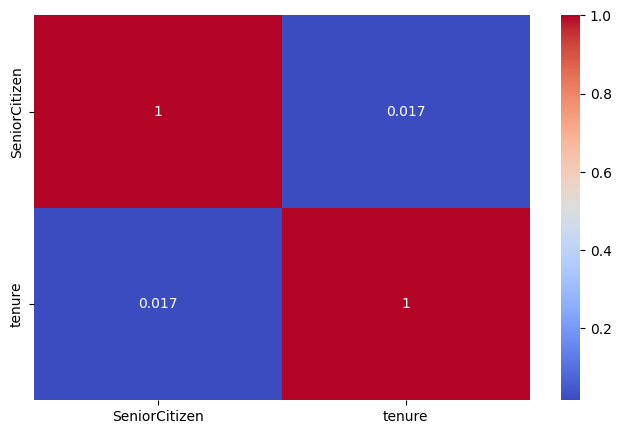

In [ ]:
# Correlation
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot = True , cmap = 'coolwarm')
plt.show()

In [ ]:
df = df.drop(columns=['customerID'], errors='ignore')

In [ ]:
cat_cols = [col for col in df.select_dtypes(include='object').columns]

In [ ]:
# One-Hot Encoding
df = pd.get_dummies(df, columns = cat_cols, drop_first = True)
df

,SeniorCitizen,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,Churn_Yes
0,0,1,False,True,False,False,True,False,False,False,False,False,False
1,0,34,True,False,False,True,False,False,False,False,False,True,False
2,0,2,True,False,False,True,False,False,False,False,False,True,True
3,0,45,True,False,False,False,True,False,False,False,False,True,False
4,0,2,False,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,True,True,True,True,False,True,False,False,False,True,False
7039,0,72,False,True,True,True,False,True,True,False,False,False,False
7040,0,11,False,True,True,False,True,False,False,False,False,True,False
7041,1,4,True,True,False,True,False,True,True,False,False,False,True


In [ ]:
df = df.astype(int)
df

,SeniorCitizen,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,Churn_Yes
0,0,1,0,1,0,0,1,0,0,0,0,0,0
1,0,34,1,0,0,1,0,0,0,0,0,1,0
2,0,2,1,0,0,1,0,0,0,0,0,1,1
3,0,45,1,0,0,0,1,0,0,0,0,1,0
4,0,2,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,1,1,1,1,0,1,0,0,0,1,0
7039,0,72,0,1,1,1,0,1,1,0,0,0,0
7040,0,11,0,1,1,0,1,0,0,0,0,1,0
7041,1,4,1,1,0,1,0,1,1,0,0,0,1


In [ ]:
# Test-Train-Split
from sklearn.model_selection import train_test_split
X = df.drop('Churn_Yes', axis = 1)
y = df['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 12) (1409, 12) (5634,) (1409,)


In [ ]:
# Normalization
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled.head()
X_test_scaled.head()

,SeniorCitizen,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes
0,-0.437749,-1.284605,-1.025166,1.031376,-0.652662,-3.034225,3.034225,-0.860523,-0.887057,-0.524081,-0.524081,-0.632534
1,-0.437749,0.353238,0.975452,-0.969579,-0.652662,0.329573,-0.329573,1.162083,-0.887057,1.908103,1.908103,-0.632534
2,-0.437749,0.803645,-1.025166,1.031376,1.532186,0.329573,-0.329573,-0.860523,-0.887057,1.908103,1.908103,-0.632534
3,-0.437749,-1.284605,-1.025166,-0.969579,-0.652662,0.329573,-0.329573,-0.860523,1.127324,-0.524081,-0.524081,-0.632534
4,-0.437749,1.417836,0.975452,-0.969579,-0.652662,0.329573,-0.329573,-0.860523,-0.887057,-0.524081,-0.524081,-0.632534


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8048261178140526
[[937  99]
 [176 197]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



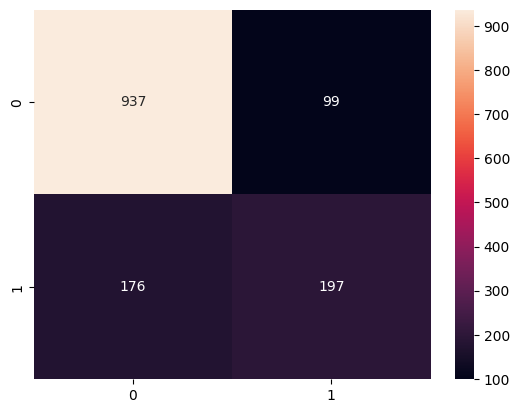

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()